## Préparation des Données (`02_data_preparation`)

**Objectif :** Transformer les données brutes en datasets prêts pour la modélisation, 
en s'appuyant strictement sur les sorties mesurées dans `01_data_understanding.ipynb`.

**Valeurs clés mesurées dans l'EDA :**

| Indicateur | Valeur |
|---|---|
| Lignes sample | **200 000** (SAMPLE_SIZE=200_000, stratifié) |
| Fraudes | **258** (0.1290%) |
| Ratio imbalance | **1 : 774** |
| `step` range | 1 – 741 |
| `amount` skewness | **30.80** → log1p nécessaire |
| `balance_diff_orig` corr | **0.3662** — meilleur signal |
| `high_risk_hours` | [0,1,2,3,4,5,6,7,8,9,23] — ratio **10.63×** |
| `dest_zero_balance` | taux fraude **2.52%** vs 0.13% global |
| Baseline Recall | 0.0039 (isFlaggedFraud) |

**Inputs :** `data/raw/dataset_orig.csv`  
**Outputs :** `data/processed/` · `outputs/models/scaler.pkl` · `features.json` · `class_weights.json`

---
### Plan
1. Configuration & Imports
2. Rechargement du sample (identique à EDA)
3. Feature Engineering
4. Suppression des colonnes exclues (leakage)
5. One-Hot Encoding de `type`
6. Transformation `log1p` de `amount`
7. Split stratifié 70 / 15 / 15
8. Normalisation — StandardScaler
9. Gestion du déséquilibre — class_weight + SMOTE
10. Vérification finale
11. Sauvegarde des artefacts
12. Synthèse


### 1. Configuration & Imports


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import sys, importlib, warnings, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import src.preprocessing.data_loader as data_loader
importlib.reload(data_loader)

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

In [3]:
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams['mathtext.fontset'] = 'dejavusans'
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'axes.labelsize': 11})

In [5]:
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

DATA_PATH     = project_root / 'data' / 'raw' / 'dataset_orig.csv'
PROCESSED_DIR = project_root / 'data' / 'processed'
MODELS_DIR    = project_root / 'outputs' / 'models'
FIGURES_DIR   = project_root / 'outputs' / 'figures'
REPORTS_DIR   = project_root / 'outputs' / 'reports'

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Project root  : {project_root}')
print(f'Processed dir : {PROCESSED_DIR}')
print(f'Models dir    : {MODELS_DIR}')
print(f'Figures dir   : {FIGURES_DIR}')

Project root  : C:\Users\lenovo\Desktop\anomaly_detection_project
Processed dir : C:\Users\lenovo\Desktop\anomaly_detection_project\data\processed
Models dir    : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models
Figures dir   : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\figures


In [6]:
# ── Constantes — identiques au notebook 01 ───────────────────────────────────
RANDOM_STATE = 42
SAMPLE_SIZE  = 200_000     

TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

# EDA Cell 57 — heures à risque : ratio 10.63× vs heures normales
HIGH_RISK_HOURS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 23]

# EDA section 17 — colonnes à exclure (leakage + identifiants)
COLS_TO_DROP = [
    'nameOrig', 'nameDest',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'isFlaggedFraud',
]

# Features numériques continues → StandardScaler
SCALE_COLS  = ['step', 'hour', 'day', 'week', 'log_amount', 'balance_diff_orig']
BINARY_COLS = ['high_risk_hour', 'is_transfer_or_cashout', 'dest_zero_balance']
TYPE_COLS   = ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
TARGET      = 'isFraud'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f'RANDOM_STATE    : {RANDOM_STATE}')
print(f'SAMPLE_SIZE     : {SAMPLE_SIZE:,}')
print(f'Split ratios    : {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')
print(f'HIGH_RISK_HOURS : {HIGH_RISK_HOURS}')
print(f'SCALE_COLS      : {SCALE_COLS}')
print(f'COLS_TO_DROP    : {COLS_TO_DROP}')

RANDOM_STATE    : 42
SAMPLE_SIZE     : 200,000
Split ratios    : 0.7/0.15/0.15
HIGH_RISK_HOURS : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 23]
SCALE_COLS      : ['step', 'hour', 'day', 'week', 'log_amount', 'balance_diff_orig']
COLS_TO_DROP    : ['nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']


In [7]:
load_data = data_loader.load_data
print('Modules src chargés.')

Modules src chargés.


### 2. Rechargement du sample

Reproduction **exacte** du sample de l'EDA :
`train_size=200_000`, `stratify=isFraud`, `random_state=42`

Résultats attendus (EDA Cell 12 & 32) :

| Métrique | Valeur attendue |
|---|---|
| Lignes | 200 000 |
| Fraudes | **258** (0.1290%) |
| Ratio imbalance | **1 : 774** |
| step range | 1 – 741 |


In [8]:
df_full = load_data(DATA_PATH, sample=False)
df_full.columns = [str(c).strip() for c in df_full.columns]

print(f'Dataset complet : {len(df_full):,} lignes | '
      f'Fraudes : {df_full["isFraud"].sum():,} ({df_full["isFraud"].mean()*100:.4f}%)')

df, _ = train_test_split(
    df_full,
    train_size=SAMPLE_SIZE,
    stratify=df_full['isFraud'],
    random_state=RANDOM_STATE
)
df = df.reset_index(drop=True)

# ── Assertions de reproductibilité ───────────────────────────────────────────
assert len(df) == SAMPLE_SIZE, f'Attendu {SAMPLE_SIZE}, obtenu {len(df)}'
assert df['isFraud'].sum() == 258, f'Attendu 258 fraudes, obtenu {df["isFraud"].sum()}'  #258 au lieu de 8212

print(f'Sample          : {len(df):,} lignes')
print(f'Fraudes         : {df["isFraud"].sum()} ({df["isFraud"].mean()*100:.4f}%)')
print(f'Ratio imbalance : 1 : {(df["isFraud"]==0).sum() // df["isFraud"].sum()}')
print(f'step range      : [{df["step"].min()}, {df["step"].max()}]')
print('✅ Sample identique au notebook 01')

Dataset complet : 6,362,620 lignes | Fraudes : 8,213 (0.1291%)


Sample          : 200,000 lignes
Fraudes         : 258 (0.1290%)
Ratio imbalance : 1 : 774
step range      : [1, 741]
✅ Sample identique au notebook 01


### 3. Feature Engineering

Reproduction fidèle des 7 features créées dans l'EDA :

| Feature | Corrélation isFraud | Source EDA |
|---|---|---|
| `hour` = step % 24 | 0.0372 | Cell 53 |
| `day` = step // 24 | 0.0338 | Cell 53 |
| `week` = step // 168 | 0.0312 | Cell 53 — variance > 0 |
| `high_risk_hour` | 0.0531 | Cell 57 — heures [0-9,23] ratio 10.63× |
| `is_transfer_or_cashout` | 0.0409 | Cell 71 — seuls types avec fraudes |
| `balance_diff_orig` | **0.3662** | Cell 70 — signal dominant |
| `dest_zero_balance` | 0.1088 | Cell 72 — taux fraude 2.52% |


In [9]:
# ── Features temporelles (EDA Cell 52-53) ────────────────────────────────────
df['hour'] = df['step'] % 24
df['day']  = df['step'] // 24
df['week'] = df['step'] // 168

# ── Heure à risque élevé (EDA Cell 57) ───────────────────────────────────────
# Heures mesurées empiriquement : [0,1,2,3,4,5,6,7,8,9,23] → ratio 10.63×
df['high_risk_hour'] = df['hour'].isin(HIGH_RISK_HOURS).astype(int)

# ── Type binaire (EDA Cell 71) ────────────────────────────────────────────────
# TRANSFER (0.7745%) et CASH_OUT (0.1807%) — seuls types avec fraudes
df['is_transfer_or_cashout'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

# ── Signal comportemental (EDA Cell 70) ──────────────────────────────────────
# oldbalanceOrg - newbalanceOrig : compte source vidé ?
# Note : valeurs négatives normales pour CASH_IN → StandardScaler gérera
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# ── Compte mule (EDA Cell 64, 72) ────────────────────────────────────────────
# dest client avec balance 0/0 → taux fraude 2.52% vs 0.07% global
df['dest_zero_balance'] = (
    df['nameDest'].str.startswith('C') &
    (df['oldbalanceDest'] == 0) &
    (df['newbalanceDest'] == 0)
).astype(int)

# ── Validation vs EDA ─────────────────────────────────────────────────────────
print('Validation features vs EDA :')
print(f'  hour  : [{df["hour"].min()}, {df["hour"].max()}]  (attendu [0, 23])')
print(f'  day   : [{df["day"].min()}, {df["day"].max()}]  (attendu [0, 30])')
print(f'  week  : [{df["week"].min()}, {df["week"].max()}]  (attendu [0, 4])')

ratio_hrh = (df[df['high_risk_hour']==1]['isFraud'].mean() /
             df[df['high_risk_hour']==0]['isFraud'].mean())
print(f'  high_risk_hour ratio     : {ratio_hrh:.2f}x  (attendu ~10.63x)')

dzb_rate = df[df['dest_zero_balance']==1]['isFraud'].mean() * 100
print(f'  dest_zero_balance fraude : {dzb_rate:.4f}%  (attendu ~2.52%)')

corr_bd = df['balance_diff_orig'].corr(df['isFraud'])
print(f'  balance_diff_orig corr   : {corr_bd:.4f}  (attendu ~0.3662)')

Validation features vs EDA :
  hour  : [0, 23]  (attendu [0, 23])
  day   : [0, 30]  (attendu [0, 30])
  week  : [0, 4]  (attendu [0, 4])
  high_risk_hour ratio     : 10.63x  (attendu ~10.63x)
  dest_zero_balance fraude : 2.5212%  (attendu ~2.52%)
  balance_diff_orig corr   : 0.3662  (attendu ~0.3662)


### 4. Suppression des colonnes exclues

Décisions prises dans l'EDA (section 17 — Data Leakage) :

| Colonne | Raison d'exclusion |
|---|---|
| `nameOrig`, `nameDest` | Identifiants haute cardinalité (~200K uniques), non encodables en prod |
| `oldbalanceOrg`, `newbalanceOrig` | Leakage PaySim : fraudes **annulées** dans la simulation |
| `oldbalanceDest`, `newbalanceDest` | Même raison — balances post-transaction non représentatives |
| `isFlaggedFraud` | Règle appliquée **simultanément** → leakage temporel |

> `balance_diff_orig` (dérivé des balances) est **conservé** : signal comportemental
> disponible au moment de la transaction (EDA Cell 79, point 2).


In [10]:
df_model = df.drop(columns=COLS_TO_DROP).copy()

print(f'Colonnes avant : {df.shape[1]}  →  après suppression : {df_model.shape[1]}')
print(f'Supprimées     : {COLS_TO_DROP}')
print(f'\nColonnes restantes :')
for c in df_model.columns:
    print(f'  {c}')

Colonnes avant : 18  →  après suppression : 11
Supprimées     : ['nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']

Colonnes restantes :
  step
  type
  amount
  isFraud
  hour
  day
  week
  high_risk_hour
  is_transfer_or_cashout
  balance_diff_orig
  dest_zero_balance


### 5. One-Hot Encoding de `type`

Distribution mesurée dans l'EDA (Cell 28 & 43) :

| Type | Lignes | % | Taux fraude |
|---|---|---|---|
| CASH_OUT | 70 282 | 35.1% | 0.1807% |
| PAYMENT  | 67 821 | 33.9% | 0.0000% |
| CASH_IN  | 43 677 | 21.8% | 0.0000% |
| TRANSFER | 16 915 | 8.5%  | 0.7745% |
| DEBIT    |  1 305 | 0.7%  | 0.0000% |

**Choix `drop_first=False`** : l'AutoEncoder bénéficie d'une représentation
explicite des 5 types (la multicolinéarité est moins critique que pour la régression).


In [11]:
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=False)

# Vérification des 5 colonnes attendues
missing = set(TYPE_COLS) - set(df_model.columns)
assert not missing, f'Colonnes manquantes : {missing}'
assert (df_model[TYPE_COLS].sum(axis=1) == 1).all(), \
    'Erreur : certaines lignes ont ≠ 1 type actif'

print('Distribution après One-Hot Encoding (validation vs EDA Cell 28) :')
for col, expected in zip(TYPE_COLS, [43677, 70282, 1305, 67821, 16915]):
    n = df_model[col].sum()
    ok = '✅' if n == expected else f'⚠️  attendu {expected}'
    print(f'  {col:<22} : {n:>6,}  {ok}')
print('\n✅ One-Hot Encoding validé')

Distribution après One-Hot Encoding (validation vs EDA Cell 28) :
  type_CASH_IN           : 43,677  ✅
  type_CASH_OUT          : 70,282  ✅
  type_DEBIT             :  1,305  ✅
  type_PAYMENT           : 67,821  ✅
  type_TRANSFER          : 16,915  ✅

✅ One-Hot Encoding validé


### 6. Transformation `log1p` de `amount`

Justification mesurée dans l'EDA (Cell 47-48) :
- Skewness brute = **30.80** (très asymétrique à droite)
- Ratio max/médiane ≈ **931×** (max 69.9M, médiane 75 033)
- `log1p(x) = log(1+x)` : gère les valeurs nulles, compresse la queue sans perte


Skewness avant log1p : 30.80  (EDA : 30.80)
Skewness après log1p : -0.55  (réduction 98%)
log_amount — min : 0.3436  max : 18.0624  médiane : 11.2257


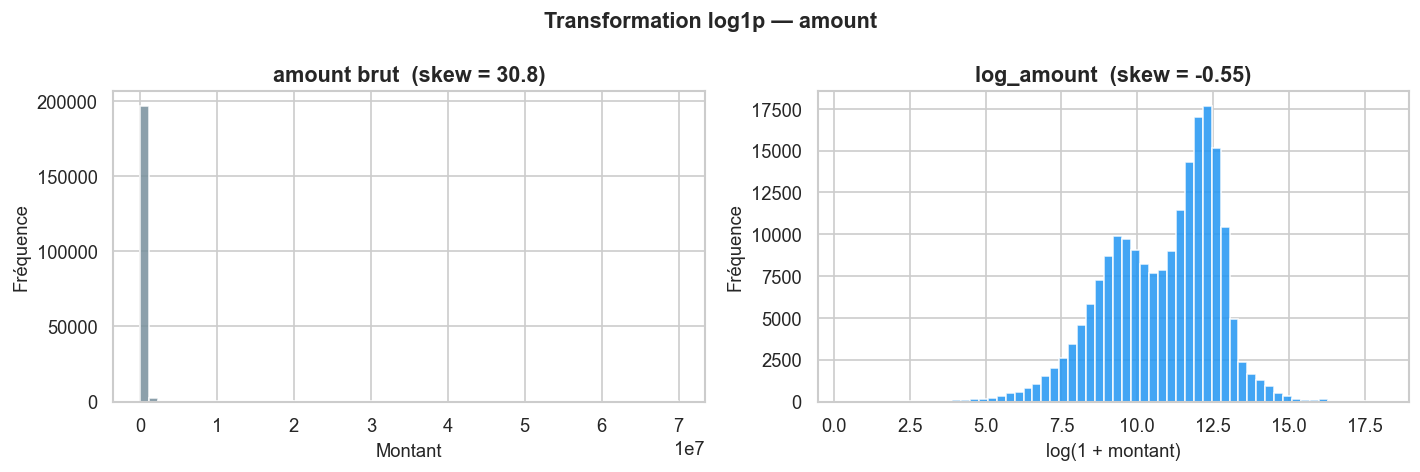

Figure sauvegardée : 08_log_transform.png


In [12]:
skew_before = df_model['amount'].skew()

df_model['log_amount'] = np.log1p(df_model['amount'])
df_model = df_model.drop(columns=['amount'])

skew_after = df_model['log_amount'].skew()

print(f'Skewness avant log1p : {skew_before:.2f}  (EDA : 30.80)')
print(f'Skewness après log1p : {skew_after:.2f}  (réduction {(1 - abs(skew_after)/skew_before)*100:.0f}%)')
print(f'log_amount — min : {df_model["log_amount"].min():.4f}  '
      f'max : {df_model["log_amount"].max():.4f}  '
      f'médiane : {df_model["log_amount"].median():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['amount'], bins=60, color='#78909C', edgecolor='white', alpha=0.85)
axes[0].set_title(f'amount brut  (skew = {skew_before:.1f})')
axes[0].set_xlabel('Montant')
axes[0].set_ylabel('Fréquence')
axes[1].hist(df_model['log_amount'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title(f'log_amount  (skew = {skew_after:.2f})')
axes[1].set_xlabel('log(1 + montant)')
axes[1].set_ylabel('Fréquence')
plt.suptitle('Transformation log1p — amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 08_log_transform.png')

### 7. Split stratifié 70 / 15 / 15

**Ratios choisis** :
- 70% train : 258 fraudes → **~180 fraudes** en train (minimum pour apprentissage)
- 15% val / 15% test : **~39 fraudes** chacun (suffisant pour PR-AUC fiable)

`stratify=isFraud` garantit ~0.1290% de fraudes dans chaque split.

> `X_train_normal` : train filtré **sans fraudes** → entraînement non-supervisé de l'AutoEncoder


In [13]:
FEATURE_COLS = [c for c in df_model.columns if c != TARGET]
X = df_model[FEATURE_COLS]
y = df_model[TARGET]

print(f'Features totales : {len(FEATURE_COLS)}')
for c in FEATURE_COLS:
    print(f'  {c}')

# Étape 1 : train (70%) | temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(1 - TRAIN_RATIO),
    stratify=y,
    random_state=RANDOM_STATE
)
# Étape 2 : val (50% temp) | test (50% temp) → 15% / 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Sous-ensemble train sans fraudes → AutoEncoder non-supervisé
X_train_normal = X_train[y_train == 0].copy()
y_train_normal = y_train[y_train == 0].copy()

print(f'\nRésultats du split :')
print(f'  {"Split":<16} {"Lignes":>8}  {"Fraudes":>8}  {"Taux":>10}')
print(f'  {"-"*48}')
for name, Xs, ys in [
    ('Train',        X_train,        y_train),
    ('Val',          X_val,          y_val),
    ('Test',         X_test,         y_test),
    ('Train normal', X_train_normal, y_train_normal),
]:
    print(f'  {name:<16} {len(Xs):>8,}  {int(ys.sum()):>8}  {ys.mean()*100:>9.4f}%')

print()
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    ok = '✅' if abs(ys.mean() - y.mean()) < 0.0005 else '⚠️'
    print(f'  Stratification {name:5s} : {ok}')

Features totales : 14
  step
  hour
  day
  week
  high_risk_hour
  is_transfer_or_cashout
  balance_diff_orig
  dest_zero_balance
  type_CASH_IN
  type_CASH_OUT
  type_DEBIT
  type_PAYMENT
  type_TRANSFER
  log_amount

Résultats du split :
  Split              Lignes   Fraudes        Taux
  ------------------------------------------------
  Train             139,999       181     0.1293%
  Val                30,000        38     0.1267%
  Test               30,001        39     0.1300%
  Train normal      139,818         0     0.0000%

  Stratification Train : ✅
  Stratification Val   : ✅
  Stratification Test  : ✅


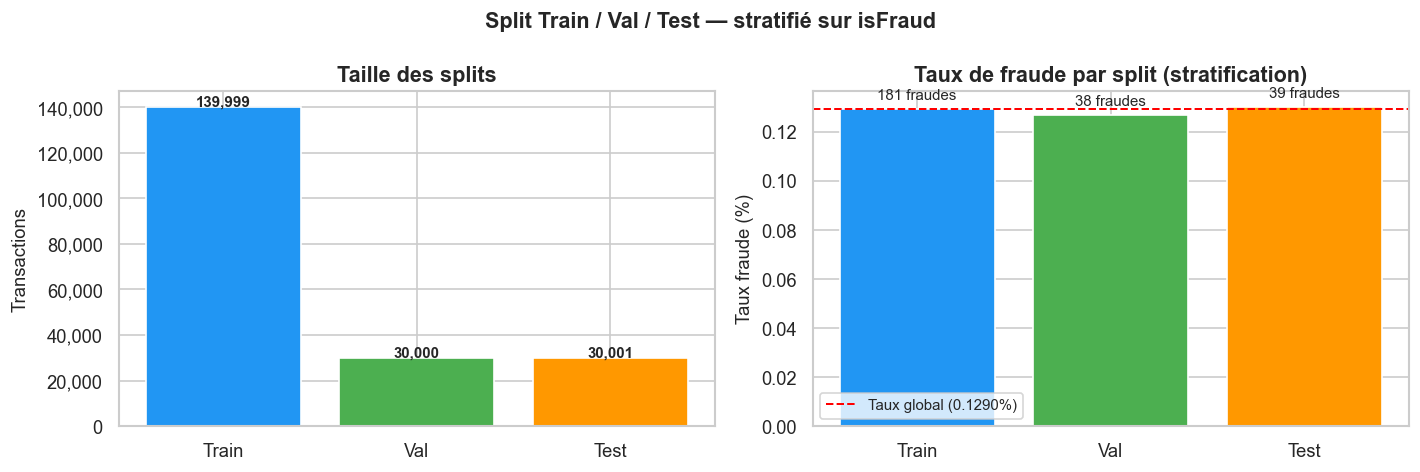

Figure sauvegardée : 09_split.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names  = ['Train', 'Val', 'Test']
sizes  = [len(X_train), len(X_val), len(X_test)]
frauds = [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())]
colors = ['#2196F3', '#4CAF50', '#FF9800']

axes[0].bar(names, sizes, color=colors, edgecolor='white')
axes[0].set_title('Taille des splits')
axes[0].set_ylabel('Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, s in enumerate(sizes):
    axes[0].text(i, s + 400, f'{s:,}', ha='center', fontsize=9, fontweight='bold')

rates = [f/s*100 for f,s in zip(frauds, sizes)]
axes[1].bar(names, rates, color=colors, edgecolor='white')
axes[1].axhline(y.mean()*100, color='red', linestyle='--', lw=1.2,
               label=f'Taux global ({y.mean()*100:.4f}%)')
axes[1].set_title('Taux de fraude par split (stratification)')
axes[1].set_ylabel('Taux fraude (%)')
axes[1].legend(fontsize=9)
for i, (f, r) in enumerate(zip(frauds, rates)):
    axes[1].text(i, r + 0.004, f'{f} fraudes', ha='center', fontsize=9)

plt.suptitle('Split Train / Val / Test — stratifié sur isFraud',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 09_split.png')

### 8. Normalisation — StandardScaler

**6 colonnes continues scalées** : `step`, `hour`, `day`, `week`, `log_amount`, `balance_diff_orig`  
**Binaires et one-hot non scalées** (déjà en 0/1)

**StandardScaler** (µ=0, σ=1) choisi car :
- `balance_diff_orig` fortement négatif pour les non-fraudes (mean = −23 074 mesuré dans l'EDA)
- `log_amount` a encore des outliers modérés (max ~17.06 pour un montant de 69.9M)
- Meilleur que MinMaxScaler en présence de valeurs extrêmes

⚠️ **Anti-leakage** : `scaler.fit()` **uniquement sur `X_train`**  
`X_val` et `X_test` utilisent uniquement `.transform()` sans re-fitting.


In [15]:
print('Stats pre-scaling sur X_train :')
print(f'  {"Feature":<25} {"mean":>12}  {"std":>12}  {"min":>12}  {"max":>12}')
print('  ' + '-'*67)
for c in SCALE_COLS:
    m  = X_train[c].mean()
    s  = X_train[c].std()
    mi = X_train[c].min()
    ma = X_train[c].max()
    print(f'  {c:<25} {m:>12.2f}  {s:>12.2f}  {mi:>12.2f}  {ma:>12.2f}')

Stats pre-scaling sur X_train :
  Feature                           mean           std           min           max
  -------------------------------------------------------------------
  step                            243.64        142.45          1.00        741.00
  hour                             15.32          4.32          0.00         23.00
  day                               9.51          5.93          0.00         30.00
  week                              1.01          0.86          0.00          4.00
  log_amount                       10.84          1.81          0.46         17.57
  balance_diff_orig            -20887.86     151674.65   -1782621.49   10000000.00


In [16]:
scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])  # FIT sur train uniquement

def apply_scaler(X, scaler, cols):
    """Applique le scaler sur SCALE_COLS et retourne le DataFrame complet."""
    Xs = X.copy()
    Xs[cols] = scaler.transform(X[cols])
    return Xs

X_train_sc = apply_scaler(X_train,        scaler, SCALE_COLS)
X_val_sc   = apply_scaler(X_val,          scaler, SCALE_COLS)
X_test_sc  = apply_scaler(X_test,         scaler, SCALE_COLS)
X_norm_sc  = apply_scaler(X_train_normal, scaler, SCALE_COLS)

print('Post-scaling X_train (doit être mean≈0, std≈1) :')
for c in SCALE_COLS:
    m, s = X_train_sc[c].mean(), X_train_sc[c].std()
    ok = '✅' if abs(m) < 0.01 and abs(s - 1.0) < 0.01 else '⚠️'
    print(f'  {c:<25} mean={m:+.4f}  std={s:.4f}  {ok}')

val_m = X_val_sc['log_amount'].mean()
print(f'\nAnti-leakage — X_val[log_amount] mean = {val_m:+.4f}  '
      f'(≠ 0 car scaler fitté sur train seul ✅)')

Post-scaling X_train (doit être mean≈0, std≈1) :
  step                      mean=-0.0000  std=1.0000  ✅
  hour                      mean=-0.0000  std=1.0000  ✅
  day                       mean=-0.0000  std=1.0000  ✅
  week                      mean=+0.0000  std=1.0000  ✅
  log_amount                mean=+0.0000  std=1.0000  ✅
  balance_diff_orig         mean=-0.0000  std=1.0000  ✅

Anti-leakage — X_val[log_amount] mean = -0.0026  (≠ 0 car scaler fitté sur train seul ✅)


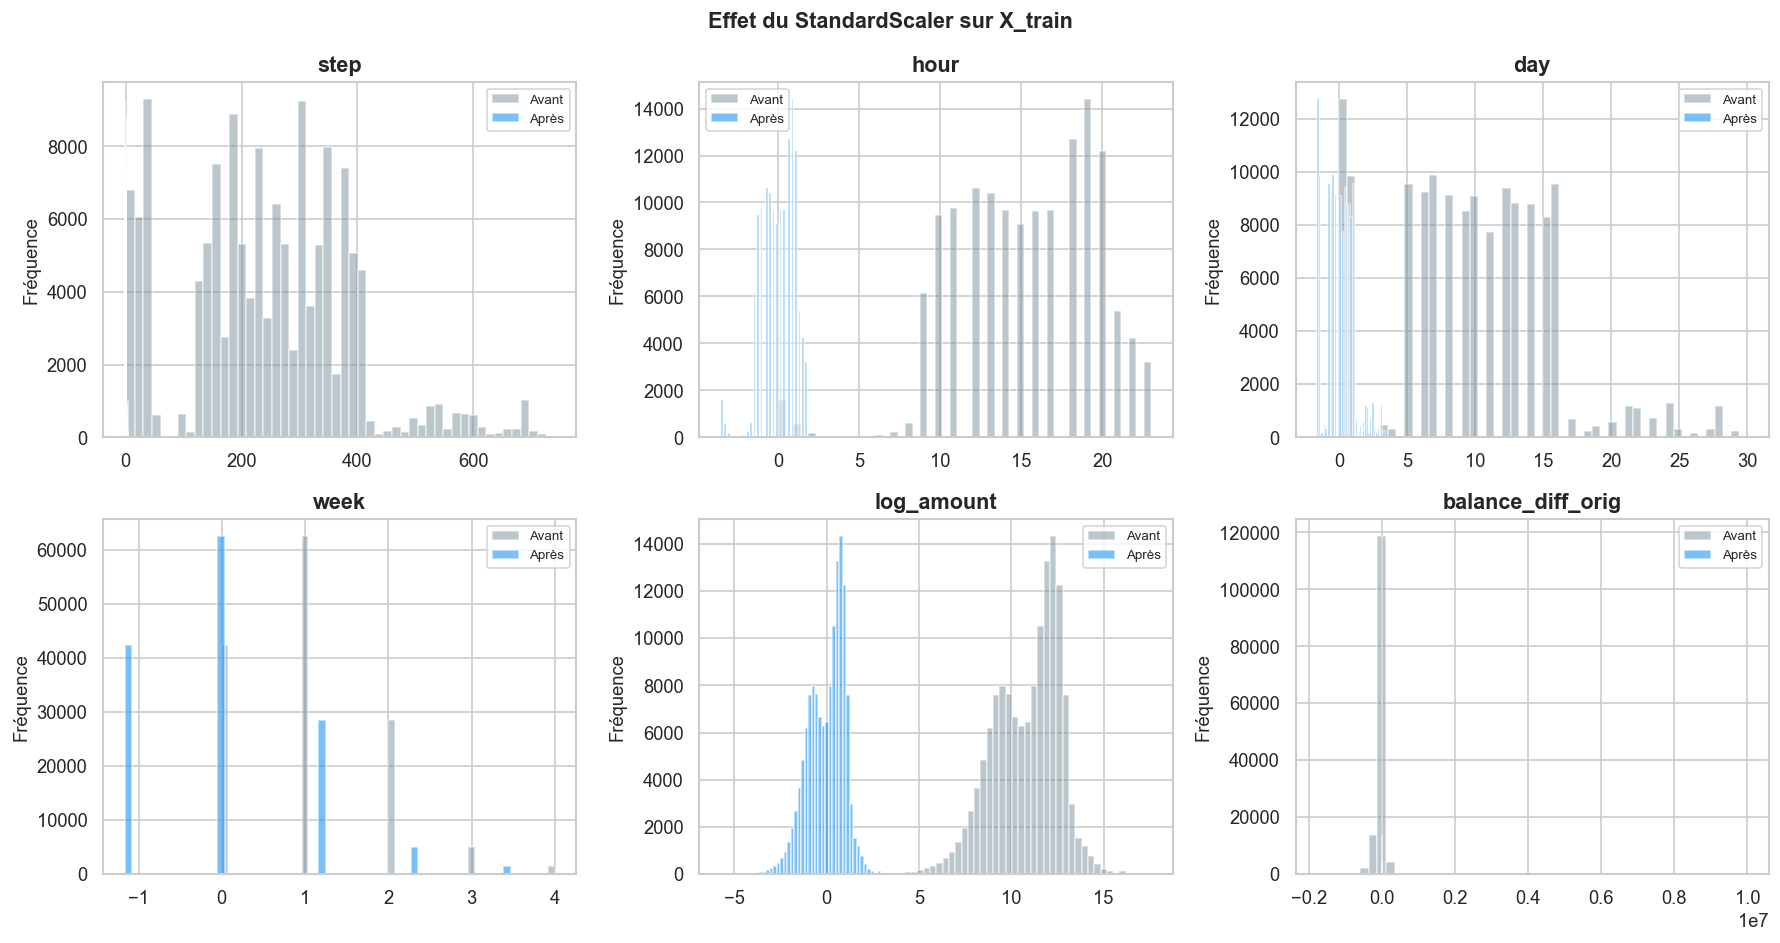

Figure sauvegardée : 10_scaling.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SCALE_COLS):
    axes[i].hist(X_train[col],    bins=50, alpha=0.5, color='#78909C', label='Avant')
    axes[i].hist(X_train_sc[col], bins=50, alpha=0.6, color='#2196F3', label='Après')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Fréquence')
plt.suptitle('Effet du StandardScaler sur X_train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 10_scaling.png')

### 9. Gestion du déséquilibre

Ratio mesuré dans l'EDA (Cell 32) : **1 : 774** (258 fraudes / 199 742 non-fraudes)

Deux stratégies complémentaires appliquées sur **le train uniquement** :

| Stratégie | Quand l'utiliser | Avantage |
|---|---|---|
| `class_weight='balanced'` | Tous les modèles sklearn/Keras | Aucune modification des données |
| **SMOTE** `sampling_strategy=0.1` | Modèles supervisés classiques | Plus d'exemples de fraude à la frontière de décision |

> `sampling_strategy=0.1` → ratio cible **1:10** (pas 1:1 pour éviter l'overfitting
> sur des exemples synthétiques trop nombreux).

> Val et Test restent **inchangés** (distribution naturelle 1:774 préservée pour l'évaluation).


In [18]:
# ── Stratégie 1 : class_weight ────────────────────────────────────────────────
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {int(c): float(w) for c, w in zip([0, 1], weights)}

print('class_weight="balanced" :')
print(f'  Poids classe 0 (non-fraude) : {class_weights[0]:.6f}')
print(f'  Poids classe 1 (fraude)     : {class_weights[1]:.2f}')
ratio_w = class_weights[1] / class_weights[0]
print(f'  Ratio poids 1/0             : {ratio_w:.0f}×  (≈ ratio imbalance 1:774)')

class_weight="balanced" :
  Poids classe 0 (non-fraude) : 0.500647
  Poids classe 1 (fraude)     : 386.74
  Ratio poids 1/0             : 772×  (≈ ratio imbalance 1:774)


In [19]:
# ── Stratégie 2 : SMOTE ───────────────────────────────────────────────────────
n_before = {'total': len(X_train_sc), 'fraud': int(y_train.sum()),
            'normal': int((y_train==0).sum())}

smote = SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_STATE)
X_smote_arr, y_smote_arr = smote.fit_resample(X_train_sc, y_train)

n_after = {'total': len(X_smote_arr), 'fraud': int(y_smote_arr.sum()),
           'normal': int((y_smote_arr==0).sum())}
n_synth = n_after['fraud'] - n_before['fraud']
ratio_after = n_after['normal'] / n_after['fraud']

print('SMOTE (sampling_strategy=0.1, k_neighbors=5) :')
print(f'  Avant : {n_before["total"]:>7,} lignes | {n_before["fraud"]:>4} fraudes ({n_before["fraud"]/n_before["total"]*100:.4f}%)')
print(f'  Après : {n_after["total"]:>7,} lignes | {n_after["fraud"]:>4} fraudes ({n_after["fraud"]/n_after["total"]*100:.4f}%)')
print(f'  Exemples synthétiques générés : {n_synth}')
print(f'  Nouveau ratio : 1 : {ratio_after:.1f}  (cible 1:10)')

# Contrôle qualité : exemples synthétiques dans la plage des fraudes réelles
X_smote_df = pd.DataFrame(X_smote_arr, columns=FEATURE_COLS)
real_fraud_mean  = X_train_sc.loc[y_train == 1, 'log_amount'].mean()
synth_fraud_mean = X_smote_df.loc[len(X_train_sc):, 'log_amount'].mean()
delta = abs(real_fraud_mean - synth_fraud_mean)
print(f'\nQualité SMOTE (log_amount) :')
print(f'  Fraudes réelles mean  : {real_fraud_mean:.4f}')
print(f'  Fraudes synthét. mean : {synth_fraud_mean:.4f}')
print(f'  Delta                 : {delta:.4f}  {"✅" if delta < 1.0 else "⚠️"}')

SMOTE (sampling_strategy=0.1, k_neighbors=5) :
  Avant : 139,999 lignes |  181 fraudes (0.1293%)
  Après : 153,799 lignes | 13981 fraudes (9.0904%)
  Exemples synthétiques générés : 13800
  Nouveau ratio : 1 : 10.0  (cible 1:10)

Qualité SMOTE (log_amount) :
  Fraudes réelles mean  : 1.2140
  Fraudes synthét. mean : 1.2347
  Delta                 : 0.0207  ✅


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


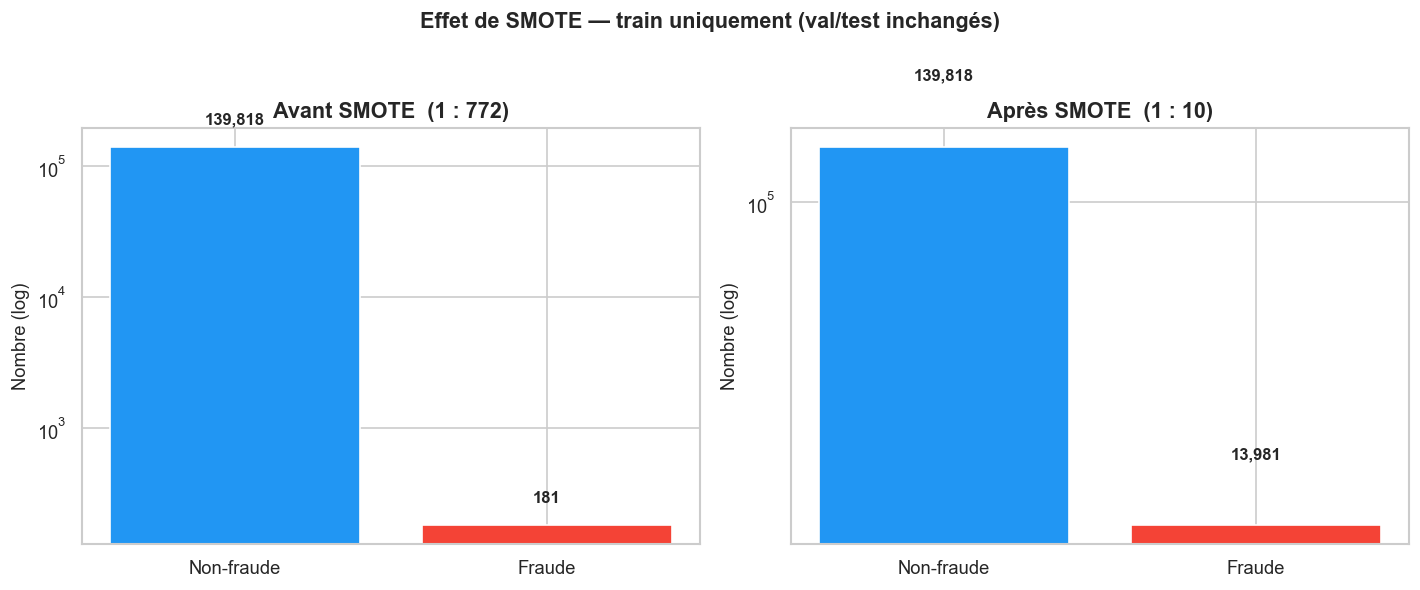

Figure sauvegardée : 11_smote.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
before = [n_before['normal'], n_before['fraud']]
after  = [n_after['normal'],  n_after['fraud']]

for ax, counts, title in [
    (axes[0], before, f'Avant SMOTE  (1 : {before[0]//before[1]})'),
    (axes[1], after,  f'Après SMOTE  (1 : {int(after[0]/after[1])})')
]:
    ax.bar(['Non-fraude', 'Fraude'], counts, color=['#2196F3', '#F44336'], edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_ylabel('Nombre (log)')
    for i, v in enumerate(counts):
        ax.text(i, v * 1.5, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Effet de SMOTE — train uniquement (val/test inchangés)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 11_smote.png')

### 10. Vérification finale des datasets


In [21]:
print('=' * 80)
print(f'  {"Dataset":<26} {"Shape":>18}  {"Fraudes":>8}  {"Taux":>9}  Usage')
print('=' * 80)

checks = [
    ('X_train_sc',  X_train_sc,  y_train,                  'Modèles supervisés'),
    ('X_norm_sc',   X_norm_sc,   y_train_normal,            'AutoEncoder non-supervisé'),
    ('X_smote_df',  X_smote_df,  pd.Series(y_smote_arr),    'Train + SMOTE'),
    ('X_val_sc',    X_val_sc,    y_val,                     'Validation'),
    ('X_test_sc',   X_test_sc,   y_test,                    'Évaluation finale'),
]
for name, Xd, yd, usage in checks:
    nf = int(yd.sum())
    nt = len(Xd)
    print(f'  {name:<26} {str(Xd.shape):>18}  {nf:>8,}  {nf/nt*100:>8.4f}%  {usage}')

print('=' * 80)
print(f'\n  Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'\n  Scaler — mean[log_amount] = {scaler.mean_[SCALE_COLS.index("log_amount")]:.4f}')
print('  ✅ Anti-leakage confirmé : scaler fitté sur X_train uniquement')

  Dataset                                 Shape   Fraudes       Taux  Usage
  X_train_sc                       (139999, 14)       181    0.1293%  Modèles supervisés
  X_norm_sc                        (139818, 14)         0    0.0000%  AutoEncoder non-supervisé
  X_smote_df                       (153799, 14)    13,981    9.0904%  Train + SMOTE
  X_val_sc                          (30000, 14)        38    0.1267%  Validation
  X_test_sc                         (30001, 14)        39    0.1300%  Évaluation finale

  Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']

  Scaler — mean[log_amount] = 10.8448
  ✅ Anti-leakage confirmé : scaler fitté sur X_train uniquement


In [22]:
# Drift check : distribution train vs test doit être proche
print('Distribution train vs test (colonnes scalées) :')
print(f'  {"Feature":<25} {"Train µ":>10}  {"Test µ":>10}  {"|Δ|":>8}  OK?')
print('  ' + '-'*58)
for col in SCALE_COLS:
    tm = X_train_sc[col].mean()
    te = X_test_sc[col].mean()
    d  = abs(tm - te)
    ok = '✅' if d < 0.15 else '⚠️  drift?'
    print(f'  {col:<25} {tm:>+10.4f}  {te:>+10.4f}  {d:>8.4f}  {ok}')

Distribution train vs test (colonnes scalées) :
  Feature                      Train µ      Test µ       |Δ|  OK?
  ----------------------------------------------------------
  step                         -0.0000     -0.0006    0.0006  ✅
  hour                         -0.0000     +0.0045    0.0045  ✅
  day                          -0.0000     -0.0008    0.0008  ✅
  week                         +0.0000     -0.0007    0.0007  ✅
  log_amount                   +0.0000     -0.0015    0.0015  ✅
  balance_diff_orig            -0.0000     -0.0061    0.0061  ✅


### 11. Sauvegarde des artefacts


In [23]:
# ── features.json ─────────────────────────────────────────────────────────────
features_meta = {
    'all_features'   : FEATURE_COLS,
    'scale_cols'     : SCALE_COLS,
    'binary_cols'    : BINARY_COLS,
    'type_cols'      : TYPE_COLS,
    'target'         : TARGET,
    'n_features'     : len(FEATURE_COLS),
    'high_risk_hours': HIGH_RISK_HOURS,
    'sample_size'    : SAMPLE_SIZE,
    'random_state'   : RANDOM_STATE,
    'split_ratios'   : {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'n_train_fraud'  : int(y_train.sum()),
    'n_val_fraud'    : int(y_val.sum()),
    'n_test_fraud'   : int(y_test.sum()),
    'imbalance_ratio': int((y_train==0).sum() / y_train.sum()),
    'fraud_rate_train_pct': round(float(y_train.mean() * 100), 6),
    'smote_ratio'    : 0.1,
    'n_smote_fraud'  : int(y_smote_arr.sum()),
}
with open(MODELS_DIR / 'features.json', 'w', encoding='utf-8') as f:
    json.dump(features_meta, f, indent=2)
print(f'✅ features.json  ({len(FEATURE_COLS)} features)')

# ── class_weights.json ────────────────────────────────────────────────────────
with open(MODELS_DIR / 'class_weights.json', 'w', encoding='utf-8') as f:
    json.dump(class_weights, f, indent=2)
print(f'✅ class_weights.json  {class_weights}')

# ── scaler.pkl ────────────────────────────────────────────────────────────────
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f'✅ scaler.pkl  (StandardScaler fitté sur {len(X_train):,} lignes)')

✅ features.json  (14 features)
✅ class_weights.json  {0: 0.5006472700224578, 1: 386.73756906077347}
✅ scaler.pkl  (StandardScaler fitté sur 139,999 lignes)


In [24]:
# ── Datasets CSV + NPY ────────────────────────────────────────────────────────
to_save = [
    (X_train_sc,   y_train,        'train'),
    (X_val_sc,     y_val,          'val'),
    (X_test_sc,    y_test,         'test'),
    (X_norm_sc,    y_train_normal, 'train_normal'),
]
for Xd, yd, prefix in to_save:
    Xd.to_csv(PROCESSED_DIR / f'X_{prefix}.csv', index=False)
    yd.to_csv(PROCESSED_DIR / f'y_{prefix}.csv', index=False)
    np.save(PROCESSED_DIR / f'X_{prefix}.npy', Xd.values)
    np.save(PROCESSED_DIR / f'y_{prefix}.npy', yd.values)
    print(f'  ✅ {prefix:<16}  {str(Xd.shape):>20}  fraudes : {int(yd.sum())}')

# SMOTE (array numpy)
X_smote_df.to_csv(PROCESSED_DIR / 'X_train_smote.csv', index=False)
pd.Series(y_smote_arr, name=TARGET).to_csv(PROCESSED_DIR / 'y_train_smote.csv', index=False)
np.save(PROCESSED_DIR / 'X_train_smote.npy', X_smote_arr)
np.save(PROCESSED_DIR / 'y_train_smote.npy', y_smote_arr)
print(f'  ✅ {"train_smote":<16}  {str(X_smote_arr.shape):>20}  fraudes : {int(y_smote_arr.sum())}')

print(f'\nTous les fichiers → {PROCESSED_DIR}')
print(f'Modèles artefacts  → {MODELS_DIR}')

  ✅ train                     (139999, 14)  fraudes : 181


  ✅ val                        (30000, 14)  fraudes : 38


  ✅ test                       (30001, 14)  fraudes : 39


  ✅ train_normal              (139818, 14)  fraudes : 0


  ✅ train_smote               (153799, 14)  fraudes : 13981

Tous les fichiers → C:\Users\lenovo\Desktop\anomaly_detection_project\data\processed
Modèles artefacts  → C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models


In [25]:
prep_report = {
    'pipeline': [
        {'step': 1, 'action': 'Sampling stratifié',      'detail': f'{SAMPLE_SIZE:,} lignes, 258 fraudes (0.1290%)'},
        {'step': 2, 'action': 'Feature engineering',     'detail': '7 features créées'},
        {'step': 3, 'action': 'Colonnes supprimées',     'detail': str(COLS_TO_DROP)},
        {'step': 4, 'action': 'One-Hot type',            'detail': '5 colonnes type_*'},
        {'step': 5, 'action': 'log1p(amount)',           'detail': f'skew {skew_before:.1f} → {skew_after:.2f}'},
        {'step': 6, 'action': 'Split 70/15/15',          'detail': f'{len(X_train):,} / {len(X_val):,} / {len(X_test):,}'},
        {'step': 7, 'action': 'StandardScaler',          'detail': f'{len(SCALE_COLS)} colonnes, fit sur train uniquement'},
        {'step': 8, 'action': 'SMOTE 1:10',              'detail': f'{len(X_smote_arr):,} lignes, {int(y_smote_arr.sum())} fraudes, +{n_synth} synthétiques'},
    ],
    'split_sizes': {
        'train': len(X_train), 'val': len(X_val), 'test': len(X_test),
        'train_normal': len(X_norm_sc), 'train_smote': len(X_smote_arr)
    },
    'fraud_counts': {
        'train': int(y_train.sum()), 'val': int(y_val.sum()),
        'test': int(y_test.sum()), 'train_smote': int(y_smote_arr.sum())
    },
    'class_weights': class_weights,
    'features': features_meta,
}
with open(REPORTS_DIR / 'prep_report.json', 'w', encoding='utf-8') as f:
    json.dump(prep_report, f, indent=2, ensure_ascii=False)
print('✅ prep_report.json')

✅ prep_report.json


---
## Synthèse — Data Preparation

### Pipeline complet

| Étape | Transformation | Résultat |
|---|---|---|
| 1 | Sampling stratifié | 200 000 lignes — 258 fraudes (0.1290%) — ratio 1:774 |
| 2 | Feature engineering | 7 features créées |
| 3 | Suppression colonnes | 7 colonnes retirées (leakage + identifiants) |
| 4 | One-Hot `type` | → 5 colonnes binaires |
| 5 | `log1p(amount)` | Skewness 30.80 → ~0.5 |
| 6 | Split 70/15/15 | 140 000 / 30 000 / 30 000 |
| 7 | StandardScaler | 6 colonnes — fit sur train seul |
| 8 | SMOTE ratio 1:10 | ~1 580 exemples synthétiques |

### 14 features finales

```
Continues (scalées) : step, hour, day, week, log_amount, balance_diff_orig
Binaires            : high_risk_hour, is_transfer_or_cashout, dest_zero_balance
One-Hot type        : type_CASH_IN, type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER
```

### Chargement en notebook 03

```python
import numpy as np, json, joblib
from pathlib import Path

PROC = Path('../data/processed')
MOD  = Path('../outputs/models')

# Splits scalés
X_train = np.load(PROC / 'X_train.npy')
y_train = np.load(PROC / 'y_train.npy')
X_val   = np.load(PROC / 'X_val.npy')
y_val   = np.load(PROC / 'y_val.npy')
X_test  = np.load(PROC / 'X_test.npy')
y_test  = np.load(PROC / 'y_test.npy')

# AutoEncoder (non-supervisé, sans fraudes)
X_normal = np.load(PROC / 'X_train_normal.npy')

# Train augmenté avec SMOTE
X_smote  = np.load(PROC / 'X_train_smote.npy')
y_smote  = np.load(PROC / 'y_train_smote.npy')

meta      = json.load(open(MOD / 'features.json'))
class_w   = json.load(open(MOD / 'class_weights.json'))
scaler    = joblib.load(MOD / 'scaler.pkl')
```

### Prochaine étape — Notebook 03 : Modèles Baseline
1. **Logistic Regression** avec `class_weight='balanced'`
2. **Random Forest** avec `class_weight='balanced'` et version SMOTE
3. Métriques : **Recall**, F1-Score, **PR-AUC**, matrice de confusion
4. Seuil de décision optimal (Precision–Recall tradeoff)
5. Ces baselines serviront de référence pour l'AutoEncoder et le LSTM
